# Predicting Customer Response to an Outreach Campaign
**Dataset:** Customer Response Campaign  
**Target:** `accepted_offer` (1 = accepted, 0 = did not accept)  
**Train size:** 32,950 rows | **Test size:** 8,238 rows  

The dataset captures customer demographics, contact history, and macroeconomic indicators at the time of outreach. The goal is to predict whether a customer will accept a product offer.


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb


In [3]:
# load data
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f"Train: {train.shape}  |  Test: {test.shape}")
train.head()


Train: (32950, 23)  |  Test: (8238, 22)


,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


## 1. Exploratory Data Analysis

Key questions:
- How imbalanced is the target?
- Which features have the strongest signal?
- Are there any outliers in the data?


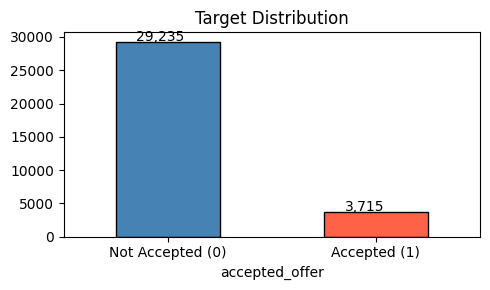

Positive rate: 11.3%


In [4]:
# About 11.3% of customers accept the offer, so this is an imbalanced binary problem.
ax = train['accepted_offer'].value_counts().plot(
    kind='bar', color=['steelblue', 'tomato'], edgecolor='black', figsize=(5, 3)
)
ax.set_xticklabels(['Not Accepted (0)', 'Accepted (1)'], rotation=0)
ax.set_title('Target Distribution')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + 0.1, p.get_height() + 200))
plt.tight_layout()
plt.show()
print(f"Positive rate: {train['accepted_offer'].mean():.1%}")


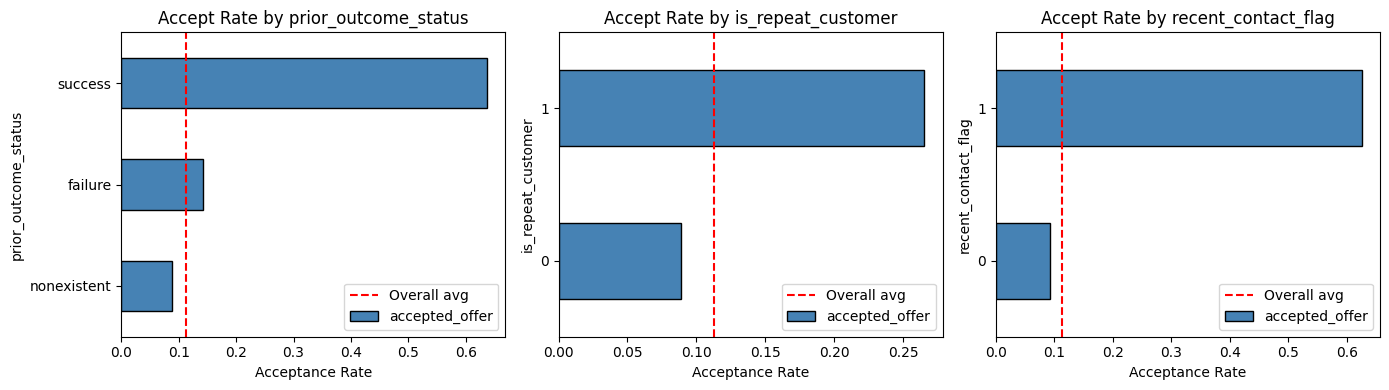

In [5]:
# Prior/recent contact fields have very strong acceptance-rate differences.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['prior_outcome_status', 'is_repeat_customer', 'recent_contact_flag']):
    rates = train.groupby(col)['accepted_offer'].mean().sort_values()
    rates.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Accept Rate by {col}')
    ax.set_xlabel('Acceptance Rate')
    ax.axvline(train['accepted_offer'].mean(), color='red', linestyle='--', label='Overall avg')
    ax.legend()

plt.tight_layout()
plt.show()


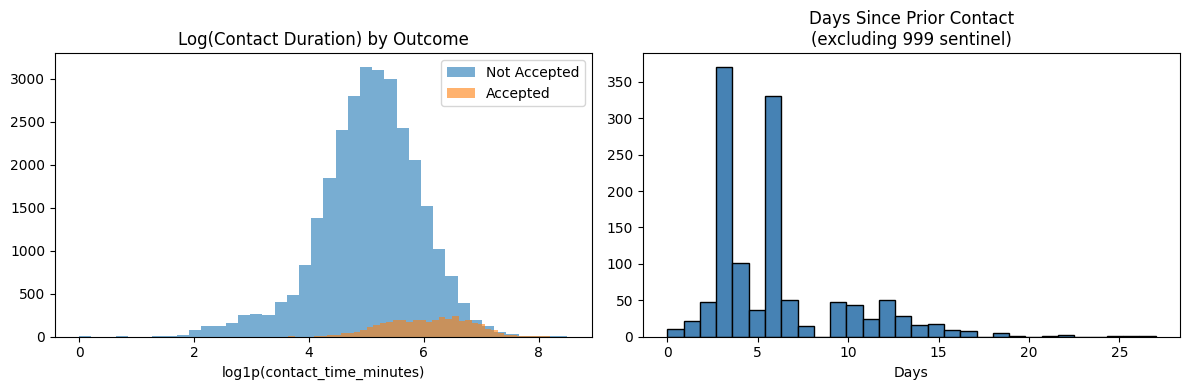

Rows with days_since_prior_contact == 999: 96.2%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# contact_time_minutes is highly right-skewed; longer calls correlate with acceptance
for label, grp in train.groupby('accepted_offer'):
    axes[0].hist(
        np.log1p(grp['contact_time_minutes']), bins=40, alpha=0.6,
        label='Accepted' if label else 'Not Accepted'
    )
axes[0].set_title('Log(Contact Duration) by Outcome')
axes[0].set_xlabel('log1p(contact_time_minutes)')
axes[0].legend()

# days_since_prior_contact: 999 is a sentinel meaning "no prior contact"
axes[1].hist(
    train.loc[train['days_since_prior_contact'] < 999, 'days_since_prior_contact'],
    bins=30, color='steelblue', edgecolor='black'
)
axes[1].set_title('Days Since Prior Contact\n(excluding 999 sentinel)')
axes[1].set_xlabel('Days')

plt.tight_layout()
plt.show()
print(f"Rows with days_since_prior_contact == 999: {(train['days_since_prior_contact'] == 999).mean():.1%}")


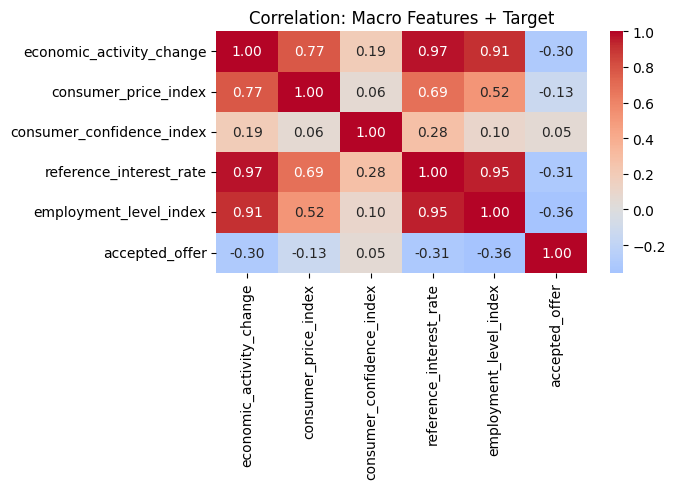

In [ ]:
# Macro features are highly correlated with each other, which can matter for linear models
macro_cols = [
    'economic_activity_change', 'consumer_price_index',
    'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index'
]

corr = train[macro_cols + ['accepted_offer']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation: Macro Features + Target')
plt.tight_layout()
plt.show()


**EDA Takeaways:**
- **11.3% positive rate**: use balanced accuracy as the primary metric because the target is imbalanced.
- **`recent_contact_flag`** and **`prior_outcome_status = success`** are among the strongest categorical signals.
- **`contact_time_minutes`** is right-skewed; a log transform may help linear models.
- **`days_since_prior_contact`** is mostly the 999 sentinel value, so a prior-contact flag is useful.
- Macro features are highly correlated; tree models can handle this naturally, while logistic regression benefits from regularization.
- **Deployment caveat:** `contact_time_minutes` may only be known after the call. If the model were used for pre-contact targeting, I would retrain without this field.


## 2. Data Preparation


In [ ]:
# train, test, and split
X = train.drop(columns=['id', 'accepted_offer'])
y = train['accepted_offer']
X_test = test.drop(columns=['id'])

# Keep "unknown" as its own category rather than treating it as missing
CAT_COLS = [
    'occupation_type', 'relationship_status', 'education_background',
    'has_credit_issue', 'mortgage_status', 'personal_loan_status',
    'last_contact_month', 'day_of_week', 'prior_outcome_status'
]
NUM_COLS = [col for col in X.columns if col not in CAT_COLS]

# Tree models use ordinal-encoded categoricals. Fit on train only; unseen test levels become -1
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
enc.fit(X[CAT_COLS])

def encode_cats(df):
    df = df.copy()
    df[CAT_COLS] = enc.transform(df[CAT_COLS])
    return df

X_enc  = encode_cats(X)
Xt_enc = encode_cats(X_test)

print("Encoded train shape:", X_enc.shape)
print("Encoded test shape: ", Xt_enc.shape)


Encoded train shape: (32950, 21)
Encoded test shape:  (8238, 21)


## 3. Feature Engineering or Feature Selection

I added two simple engineered features based on EDA, then tested whether feature engineering or Random Forest feature selection improved or simplified the boosting-tree model. Feature selection is evaluated inside cross-validation to avoid target leakage.


In [ ]:
def engineer_features(df):
    df = df.copy()

    # days_since_prior_contact == 999 means "never contacted before"
    df['was_previously_contacted'] = (df['days_since_prior_contact'] < 999).astype(int)

    # Log-transform contact duration because it is strongly right-skewed
    df['log_contact_time'] = np.log1p(df['contact_time_minutes'])

    # Replace the 999 sentinel with 0 so the numeric field reflects elapsed days when present
    df['days_since_prior_contact'] = df['days_since_prior_contact'].replace(999, 0)
    return df

# Engineered matrices for tree models
X_fe  = engineer_features(X_enc)
Xt_fe = engineer_features(Xt_enc)

# Same engineered features on raw categoricals for the logistic-regression preprocessing pipeline
X_fe_lr  = engineer_features(X)
Xt_fe_lr = engineer_features(X_test)

print("Features after engineering:", X_fe.shape[1])
print("New features:", ['was_previously_contacted', 'log_contact_time'])


Features after engineering: 23
New features: ['was_previously_contacted', 'log_contact_time']


Original encoded features        Balanced Accuracy: 0.8933 +/- 0.0085
Engineered features              Balanced Accuracy: 0.8921 +/- 0.0094


c:\Users\Owner\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Owner\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Owner\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Owner\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Owner\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


RF-selected engineered features  Balanced Accuracy: 0.8897 +/- 0.0085


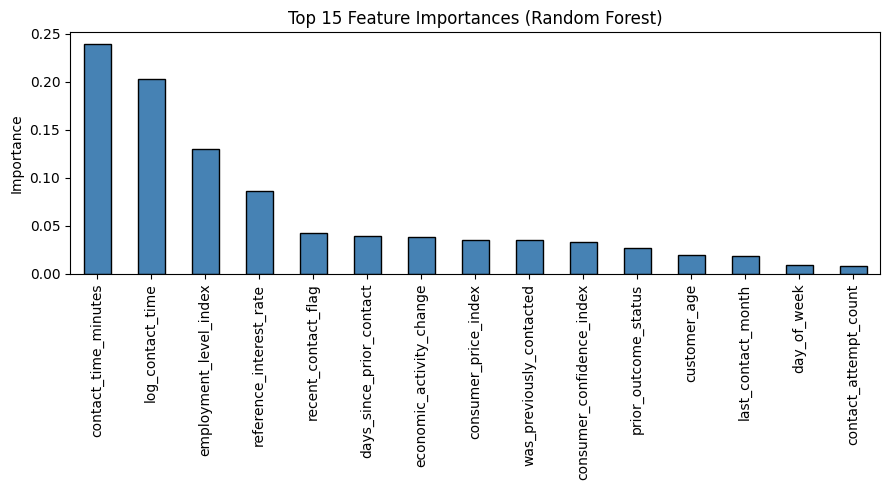

Final tree-model feature count: 23


,CV Balanced Accuracy
Original encoded features,0.893258
Engineered features,0.892142
RF-selected engineered features,0.889706


In [ ]:
# Compare feature choices with the same tuned LightGBM-style model
# quick check to see if engineered features add any value
feature_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
feature_check_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=30,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

feature_results = {}
for label, X_candidate in [
    ('Original encoded features', X_enc),
    ('Engineered features', X_fe),
]:
    scores = cross_val_score(clone(feature_check_model), X_candidate, y,
                             cv=feature_cv, scoring='balanced_accuracy', n_jobs=1)
    feature_results[label] = scores.mean()
    print(f"{label:32s} Balanced Accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")

selector_pipeline = Pipeline([
    ('selector', SelectFromModel(
        RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42, n_jobs=-1),
        threshold='median'
    )),
    ('model', clone(feature_check_model))
])
selection_scores = cross_val_score(selector_pipeline, X_fe, y, cv=feature_cv,
                                   scoring='balanced_accuracy', n_jobs=1)
feature_results['RF-selected engineered features'] = selection_scores.mean()
print(f"{'Random Forest engineered features':32s} Balanced Accuracy: {selection_scores.mean():.4f} +/- {selection_scores.std():.4f}")

# Fit once on all training data for interpretation only; final CV scores above avoid selection leakage
rf_selector = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42, n_jobs=-1)
rf_selector.fit(X_fe, y)
feat_imp = pd.Series(rf_selector.feature_importances_, index=X_fe.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# Keep all engineered features for the final tree models because selection did not improve balanced accuracy
X_final  = X_fe
Xt_final = Xt_fe
print("Final tree-model feature count:", X_final.shape[1])

feature_summary = pd.Series(feature_results, name='CV Balanced Accuracy').sort_values(ascending=False).to_frame()
feature_summary


**Feature decision:** Feature engineering did not improve performance much. However, it still helps with interpretation. The Random Forest engineered features slightly reduced Balanced Accuracy, so the final models keep all the engineered included inside the models.


## 4. Modeling and Evaluation

**Cross Validation:** Stratified 5-fold cross-validation (preserves class balance across folds)  
**Primary metric:** Balanced Accuracy (appropriate for imbalanced binary classification)  

Three meaningfully different models:
1. **Logistic Regression**: regularized linear baseline with one-hot categoricals and scaled numeric features
2. **LightGBM**: leaf-wise gradient boosted trees on ordinal-encoded engineered features
3. **XGBoost**: depth-wise gradient boosted trees with different split and regularization behavior


In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_balanced_accuracy(model, X, y, label=''):
    # Keep CV serial and let the estimators handle their own parallelism; this is stable on Windows.
    scores = cross_val_score(model, X, y, cv=cv, scoring='balanced_accuracy', n_jobs=1)
    print(f"{label:30s}  Balanced Accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")
    return scores.mean()

results = {}


In [26]:
# Logistic Regression gets one-hot categorical features and scaled numeric features.
numeric_cols_lr = [col for col in X_fe_lr.columns if col not in CAT_COLS]

lr_preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols_lr),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS)
])

lr = Pipeline([
    ('preprocess', lr_preprocess),
    ('clf', LogisticRegression(
        C=0.1,
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    ))
])

results['Logistic Regression'] = cv_balanced_accuracy(lr, X_fe_lr, y, 'Logistic Regression (C=0.1)')


Logistic Regression (C=0.1)     Balanced Accuracy: 0.8758 +/- 0.0030


In [28]:
lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=60,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

results['LightGBM'] = cv_balanced_accuracy(lgbm, X_final, y, 'LightGBM')


LightGBM                        Balanced Accuracy: 0.8790 +/- 0.0073


In [29]:
xgbm = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

results['XGBoost'] = cv_balanced_accuracy(xgbm, X_final, y, 'XGBoost')


XGBoost                         Balanced Accuracy: 0.8870 +/- 0.0076


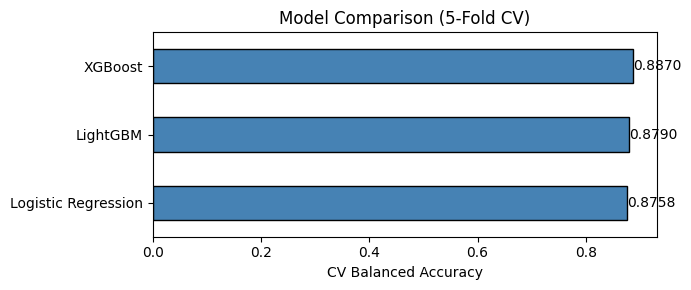

In [30]:
res_df = pd.Series(results).sort_values()
ax = res_df.plot(kind='barh', figsize=(7, 3), color='steelblue', edgecolor='black')
ax.set_xlabel('CV Balanced Accuracy')
ax.set_title('Model Comparison (5-Fold CV)')
for i, v in enumerate(res_df):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()


## 5. Ensembling

Combining LightGBM and XGBoost averages their predicted probabilities. These two models are different. LightGBM grows trees leaf-wise, while XGBoost grows depth-wise with different split and regularization behavior. Logistic Regression is excluded from the ensemble because it is weaker than the other two models and probably decreases the signal.


In [31]:
# average predicted probabilities from the two boosted-tree models.
ensemble = VotingClassifier(
    estimators=[
        ('lgbm', lgbm),
        ('xgb',  xgbm)
    ],
    voting='soft',
    n_jobs=1
)

results['Ensemble (LGBM + XGB)'] = cv_balanced_accuracy(ensemble, X_final, y, 'Ensemble (LGBM + XGB)')

print("\nFinal Comparison")
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:30s}  {score:.4f}")


Ensemble (LGBM + XGB)           Balanced Accuracy: 0.8820 +/- 0.0060

Final Comparison
  XGBoost                         0.8870
  Ensemble (LGBM + XGB)           0.8820
  LightGBM                        0.8790
  Logistic Regression             0.8758


In [32]:
best_single = max(results['LightGBM'], results['XGBoost'])
ens_score   = results['Ensemble (LGBM + XGB)']
print(f"Best single boosted-tree: {best_single:.4f}")
print(f"Ensemble Balanced Accuracy: {ens_score:.4f}")
print(f"Ensemble lift: {ens_score - best_single:+.4f}")

model_inputs = {
    'Logistic Regression': (lr, X_fe_lr, Xt_fe_lr),
    'LightGBM': (lgbm, X_final, Xt_final),
    'XGBoost': (xgbm, X_final, Xt_final),
    'Ensemble (LGBM + XGB)': (ensemble, X_final, Xt_final)
}

final_model_name = max(results, key=results.get)
final_model, final_train_X, final_test_X = model_inputs[final_model_name]
print(f"Selected final model: {final_model_name}")


Best single boosted-tree: 0.8870
Ensemble Balanced Accuracy: 0.8820
Ensemble lift: -0.0050
Selected final model: XGBoost


## 6. Results Summary

The table below summarizes the validation results from the runs above. The final model is selected based on cross-validated training performance.


In [33]:
summary_rows = [
    {
        'Model': 'Logistic Regression',
        'Key preprocessing / features': 'Engineered features, one-hot categoricals, scaled numerics, class_weight=balanced',
        'Validation': 'Stratified 5-fold CV',
        'Metric': 'Balanced Accuracy',
        'Validation score': results['Logistic Regression'],
        'Reason / role': 'Interpretable regularized linear baseline'
    },
    {
        'Model': 'LightGBM',
        'Key preprocessing / features': 'Train-only ordinal encoding, engineered features, scale_pos_weight',
        'Validation': 'Stratified 5-fold CV',
        'Metric': 'Balanced Accuracy',
        'Validation score': results['LightGBM'],
        'Reason / role': 'Strong non-linear boosted-tree model'
    },
    {
        'Model': 'XGBoost',
        'Key preprocessing / features': 'Train-only ordinal encoding, engineered features, scale_pos_weight',
        'Validation': 'Stratified 5-fold CV',
        'Metric': 'Balanced Accuracy',
        'Validation score': results['XGBoost'],
        'Reason / role': 'Complementary boosted-tree model with different regularization'
    },
    {
        'Model': 'Ensemble (LGBM + XGB)',
        'Key preprocessing / features': 'Soft-vote average of LightGBM and XGBoost probabilities',
        'Validation': 'Stratified 5-fold CV',
        'Metric': 'Balanced Accuracy',
        'Validation score': results['Ensemble (LGBM + XGB)'],
        'Reason / role': 'Tests whether combining complementary tree models improves Balanced Accuracy'
    }
]

summary_df = pd.DataFrame(summary_rows)
summary_df['Final model'] = summary_df['Model'].eq(final_model_name)
summary_df['Validation score'] = summary_df['Validation score'].map(lambda x: f"{x:.4f}")
summary_df


,Model,Key preprocessing / features,Validation,Metric,Validation score,Reason / role,Final model
0,Logistic Regression,"Engineered features, one-hot categoricals, sca...",Stratified 5-fold CV,Balanced Accuracy,0.8758,Interpretable regularized linear baseline,False
1,LightGBM,"Train-only ordinal encoding, engineered featur...",Stratified 5-fold CV,Balanced Accuracy,0.8790,Strong non-linear boosted-tree model,False
2,XGBoost,"Train-only ordinal encoding, engineered featur...",Stratified 5-fold CV,Balanced Accuracy,0.8870,Complementary boosted-tree model with differen...,True
3,Ensemble (LGBM + XGB),Soft-vote average of LightGBM and XGBoost prob...,Stratified 5-fold CV,Balanced Accuracy,0.8820,Tests whether combining complementary tree mod...,False


## 7. Final Model and Predictions

I trained the selected final model (XGBoost) on the full training set to generate predicted probabilities for the test set.


Fitting final model on full training set: XGBoost
Submission saved to submission.csv: 8238 rows
      id  accepted_offer
0  32884        0.000128
1   3169        0.813817
2  32206        0.881639
3   9403        0.046889
4  14020        0.000664
5  17201        0.003366
6    879        0.019368
7  23757        0.917239
8  10821        0.292672
9  14355        0.000133


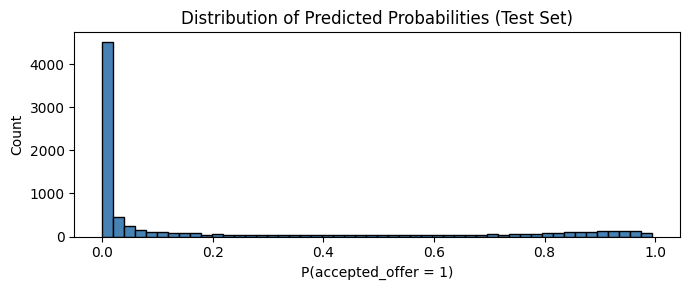


Predicted positive rate (threshold=0.5): 21.4%


In [34]:
# Fit the selected final model on all training data.
print(f"Fitting final model on full training set: {final_model_name}")
final_model.fit(final_train_X, y)

# Generate predicted probabilities for the test set.
test_probs = final_model.predict_proba(final_test_X)[:, 1]

# Build submission file.
submission = pd.DataFrame({
    'id': test['id'],
    'accepted_offer': test_probs
})

submission_path = 'submission.csv'
submission.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}: {submission.shape[0]} rows")
print(submission.head(10))

# Sanity check: distribution of predicted probabilities.
plt.figure(figsize=(7, 3))
plt.hist(test_probs, bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Predicted Probabilities (Test Set)')
plt.xlabel('P(accepted_offer = 1)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"\nPredicted positive rate (threshold=0.5): {(test_probs >= 0.5).mean():.1%}")
